In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import datetime

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.float_format", lambda x: "%.2f" % x)



In [2]:
df_raw = pd.read_csv("used_cars_UK.csv")
df = df_raw.copy()


In [3]:
print(f"Satır Sayısı  : {df.shape[0]:,}")
print(f"Sütun Sayısı  : {df.shape[1]}")

print(df.info())

display(df.head())

print(df.isnull().sum()[df.isnull().sum() > 0])

Satır Sayısı  : 3,685
Sütun Sayısı  : 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3685 non-null   int64  
 1   title              3685 non-null   object 
 2   Price              3685 non-null   int64  
 3   Mileage(miles)     3685 non-null   int64  
 4   Registration_Year  3685 non-null   int64  
 5   Previous Owners    2276 non-null   float64
 6   Fuel type          3685 non-null   object 
 7   Body type          3685 non-null   object 
 8   Engine             3640 non-null   object 
 9   Gearbox            3685 non-null   object 
 10  Doors              3660 non-null   float64
 11  Seats              3650 non-null   float64
 12  Emission Class     3598 non-null   object 
 13  Service history    540 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 403.2+ KB
None


,Unnamed: 0,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,0,SKODA Fabia,6900,70189,2016,3.00,Diesel,Hatchback,1.4L,Manual,5.00,5.00,Euro 6,NaN
1,1,Vauxhall Corsa,1495,88585,2008,4.00,Petrol,Hatchback,1.2L,Manual,3.00,5.00,Euro 4,Full
2,2,Hyundai i30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.00,5.00,Euro 5,NaN
3,3,MINI Hatch,2395,96731,2010,5.00,Petrol,Hatchback,1.4L,Manual,3.00,4.00,Euro 4,Full
4,4,Vauxhall Corsa,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.00,5.00,Euro 5,NaN


Previous Owners    1409
Engine               45
Doors                25
Seats                35
Emission Class       87
Service history    3145
dtype: int64


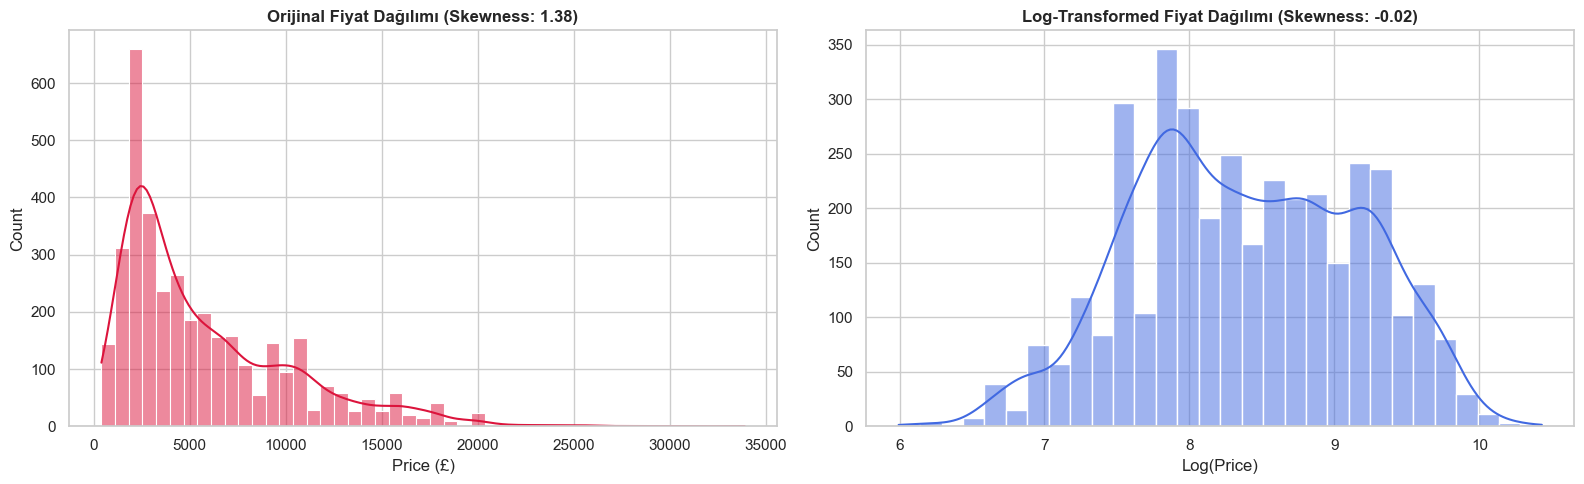

count    3685.00
mean     5787.15
std      4480.81
min       400.00
25%      2490.00
50%      4000.00
75%      7995.00
max     33900.00
Name: Price, dtype: float64


In [4]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

df["Engine_Size"] = (
    df["Engine"].str.replace("L", "", regex=False).str.strip().astype(float)
)
df.drop("Engine", axis=1, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["Price"], kde=True, ax=axes[0], color="crimson")
axes[0].set_title(
    f"Orijinal Fiyat Dağılımı (Skewness: {df['Price'].skew():.2f})",
    weight="bold",
)
axes[0].set_xlabel("Price (£)")

sns.histplot(np.log1p(df["Price"]), kde=True, ax=axes[1], color="royalblue")
axes[1].set_title(
    f"Log-Transformed Fiyat Dağılımı (Skewness: {np.log1p(df['Price']).skew():.2f})",
    weight="bold",
)
axes[1].set_xlabel("Log(Price)")

plt.tight_layout()
plt.show()

print(df["Price"].describe())

In [5]:
df["Service history"] = df["Service history"].fillna("Unknown")

median_owners = df["Previous Owners"].median()
df["Previous Owners"] = df["Previous Owners"].fillna(median_owners)

df["Engine_Size"] = df.groupby(["Body type", "Fuel type"])[
    "Engine_Size"
].transform(lambda x: x.fillna(x.median()))

df["Engine_Size"] = df["Engine_Size"].fillna(df["Engine_Size"].median())

for col in ["Doors", "Seats"]:
    df[col] = df.groupby("Body type")[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
    )

df["Emission Class"] = df.groupby("Registration_Year")[
    "Emission Class"
].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Euro 5")
)

print(f"Toplam Eksik Veri Sayısı: {df.isnull().sum().sum()}")

Toplam Eksik Veri Sayısı: 1


In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

Doors    1
dtype: int64

In [7]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ["float64", "int64"]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [9]:
current_year = 2026
df["Car_Age"] = current_year - df["Registration_Year"]
df["Car_Age"] = df["Car_Age"].apply(lambda x: 1 if x <= 0 else x)

df["Miles_Per_Year"] = df["Mileage(miles)"] / df["Car_Age"]

df["Brand"] = df["title"].apply(lambda x: str(x).split()[0] if pd.notnull(x) else "Unknown")
df["Model"] = df["title"].apply(lambda x: " ".join(str(x).split()[1:]) if len(str(x).split()) > 1 else "Unknown")

df["Engine_Per_Age"] = df["Engine_Size"] / df["Car_Age"]

display(df[["title", "Brand", "Model", "Car_Age", "Miles_Per_Year", "Engine_Per_Age"]].head())

,title,Brand,Model,Car_Age,Miles_Per_Year,Engine_Per_Age
0,SKODA Fabia,SKODA,Fabia,10,7018.90,0.14
1,Vauxhall Corsa,Vauxhall,Corsa,18,4921.39,0.07
2,Hyundai i30,Hyundai,i30,15,9133.33,0.09
3,MINI Hatch,MINI,Hatch,16,6045.69,0.09
4,Vauxhall Corsa,Vauxhall,Corsa,13,6538.46,0.10


In [10]:
df_model = df.drop(columns=["title"])

ohe_cols = [
    "Fuel type",
    "Body type",
    "Gearbox",
    "Emission Class",
    "Service history",
]

df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

print(f"Yeni Sütun Sayısı: {df_model.shape[1]}")
display(df_model.head())

Yeni Sütun Sayısı: 33


,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats,Engine_Size,Car_Age,Miles_Per_Year,Brand,...,Body type_Pickup,Body type_SUV,Body type_Saloon,Gearbox_Manual,Emission Class_Euro 2,Emission Class_Euro 3,Emission Class_Euro 4,Emission Class_Euro 5,Emission Class_Euro 6,Service history_Unknown
0,6900,70189,2016,3.00,5.00,5.00,1.40,10,7018.90,SKODA,...,False,False,False,True,False,False,False,False,True,True
1,1495,88585,2008,4.00,3.00,5.00,1.20,18,4921.39,Vauxhall,...,False,False,False,True,False,False,True,False,False,False
2,949,137000,2011,3.00,5.00,5.00,1.40,15,9133.33,Hyundai,...,False,False,False,True,False,False,False,True,False,True
3,2395,96731,2010,5.00,3.00,4.00,1.40,16,6045.69,MINI,...,False,False,False,True,False,False,True,False,False,False
4,1000,85000,2013,3.00,5.00,5.00,1.30,13,6538.46,Vauxhall,...,False,False,False,True,False,False,False,True,False,True


In [11]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Price"])
y = np.log1p(df_model["Price"])  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train Seti Boyutu : {X_train.shape}")
print(f"Test Seti Boyutu  : {X_test.shape}")

target_enc_cols = ["Brand", "Model"]

for col in target_enc_cols:
    encoding_map = y_train.groupby(X_train[col]).mean()

    global_mean = y_train.mean()

    X_train[f"{col}_encoded"] = X_train[col].map(encoding_map).fillna(global_mean)
    X_test[f"{col}_encoded"] = X_test[col].map(encoding_map).fillna(global_mean)

    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)


display(X_train.head(3))

Train Seti Boyutu : (2948, 32)
Test Seti Boyutu  : (737, 32)


,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats,Engine_Size,Car_Age,Miles_Per_Year,Engine_Per_Age,Fuel type_Diesel Hybrid,...,Body type_Saloon,Gearbox_Manual,Emission Class_Euro 2,Emission Class_Euro 3,Emission Class_Euro 4,Emission Class_Euro 5,Emission Class_Euro 6,Service history_Unknown,Brand_encoded,Model_encoded
1001,55301,2016,3.00,5.00,5.00,1.60,10,5530.10,0.16,False,...,False,True,False,False,False,False,True,True,8.32,8.70
2494,49482,2017,2.00,5.00,5.00,1.00,9,5498.00,0.11,False,...,False,True,False,False,False,False,True,True,8.22,8.48
1284,122000,2010,5.00,5.00,5.00,1.60,16,7625.00,0.10,False,...,False,True,False,False,False,True,False,True,8.20,7.96


In [12]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6, verbose=0, random_seed=42
    ),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)

    r2 = r2_score(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)

    results.append(
        {"Model": name, "R2 Score": r2, "RMSE (£)": rmse, "MAE (£)": mae}
    )

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

display(results_df)

,Model,R2 Score,RMSE (£),MAE (£)
1,XGBoost,0.88,1591.14,785.38
2,LightGBM,0.88,1609.01,793.42
3,CatBoost,0.87,1673.92,876.73
0,Random Forest,0.86,1721.88,801.29


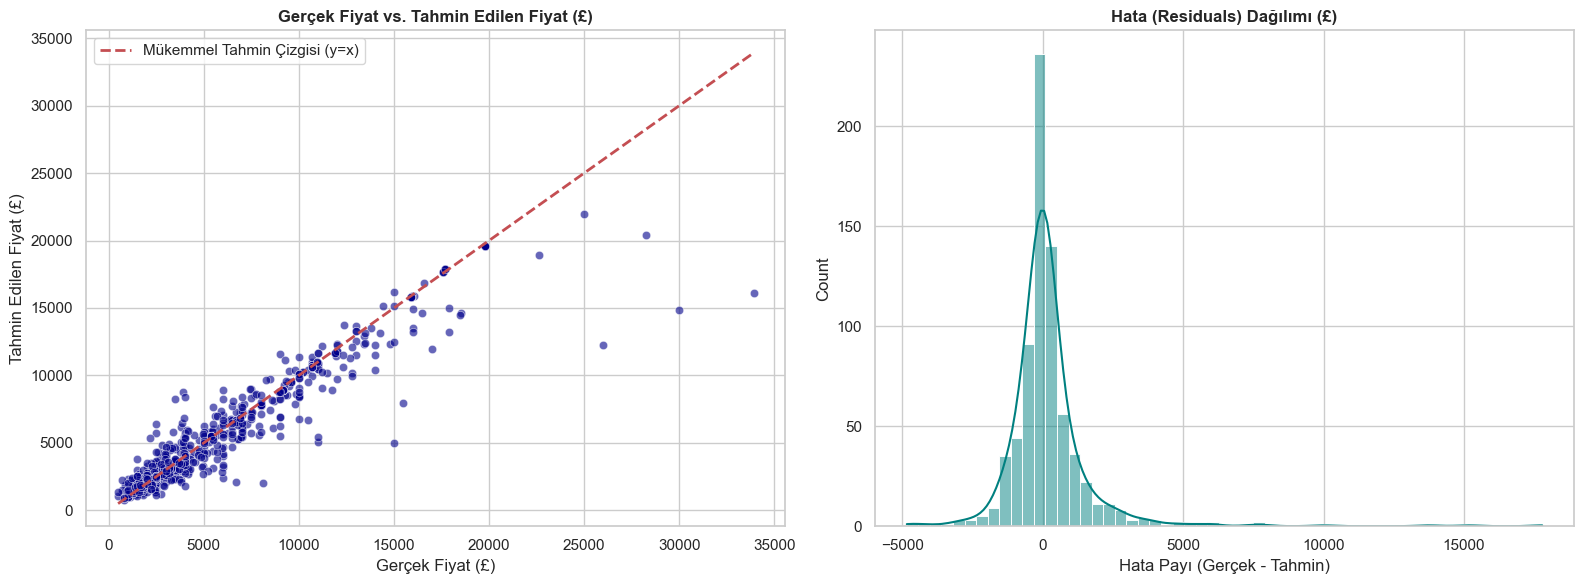

,Actual_Price,Predicted_Price,Absolute_Error_(£),Percentage_Error_(%),Car_Age,Miles_Per_Year,Brand_encoded
3210,33900.00,16111.68,17788.32,52.47,7,13142.86,8.63
2934,30000.00,14828.15,15171.85,50.57,9,5111.11,8.93
3228,25995.00,12270.71,13724.29,52.80,11,3305.73,8.93
2510,15000.00,5012.62,9987.38,66.58,23,2640.96,7.47
3222,28240.00,20424.41,7815.59,27.68,7,6450.71,8.76


In [13]:
best_xgb = models["XGBoost"]
y_pred_xgb_log = best_xgb.predict(X_test)

y_pred_actual = np.expm1(y_pred_xgb_log)
y_test_actual = np.expm1(y_test)

residuals = y_test_actual - y_pred_actual

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x=y_test_actual,
    y=y_pred_actual,
    alpha=0.6,
    color="darkblue",
    ax=axes[0],
)
axes[0].plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--",
    lw=2,
    label="Mükemmel Tahmin Çizgisi (y=x)",
)
axes[0].set_title("Gerçek Fiyat vs. Tahmin Edilen Fiyat (£)", weight="bold")
axes[0].set_xlabel("Gerçek Fiyat (£)")
axes[0].set_ylabel("Tahmin Edilen Fiyat (£)")
axes[0].legend()

sns.histplot(residuals, kde=True, color="teal", ax=axes[1])
axes[1].set_title("Hata (Residuals) Dağılımı (£)", weight="bold")
axes[1].set_xlabel("Hata Payı (Gerçek - Tahmin)")

plt.tight_layout()
plt.show()

analysis_df = X_test.copy()
analysis_df["Actual_Price"] = y_test_actual
analysis_df["Predicted_Price"] = y_pred_actual
analysis_df["Absolute_Error_(£)"] = np.abs(residuals)
analysis_df["Percentage_Error_(%)"] = (
    analysis_df["Absolute_Error_(£)"] / analysis_df["Actual_Price"]
) * 100

display(
    analysis_df.sort_values(by="Absolute_Error_(£)", ascending=False)[
        [
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error_(£)",
            "Percentage_Error_(%)",
            "Car_Age",
            "Miles_Per_Year",
            "Brand_encoded",
        ]
    ].head(5)
)